In [1]:
# A spelling bee solver:
# A spelling bee has 7 letters, 1 of which is the "center" and must be included in all words
# Words must be at least 4 letters, scoring as follows:
    # 4 letters: 1 point
    # n letters where n>4: n points
    # If a word uses all 7 letters: n+7 points

In [2]:
import json

with open("C:/Users/benvk/courses/For Funsies/Spelling Bee/Collins Scrabble Words (2019).txt", "r") as f:
    words = [line.strip() for line in f]

In [3]:

words = [w for w in words if len(w) >= 4 and len(set(w)) <= 7] # A word is only considered if it is 4+ letters and <= 7 unique letters

In [4]:
print(len(words))

152380


In [5]:
pangrams = [w for w in words if len(set(w)) >= 7]

In [6]:
print(len(pangrams))
# There are 60603 pangrams (words that use each of the 7 letters AT LEAST once)

60603


In [7]:
max_word = ""  
for p in pangrams:  
    if len(p) > len(max_word):  
        max_word = p
print(max_word)
print(len(max_word))

# The longest pangram is ACCESSARINESSES, which has 15 letters but still only 7 distinct letters)

ACCESSARINESSES
15


In [8]:
perfect_pangrams = [p for p in pangrams if len(p) == 7]
print(len(perfect_pangrams))
# There are 11258 perfect pangrams (words that use each of the 7 letters EXACTLY once)

11258


In [9]:
# Finding all possible puzzles from the pangrams: Generating each possible puzzle from the set of pangrams.
puzzle_sets = set(frozenset(w) for w in pangrams)

In [10]:
print(len(puzzle_sets))

# There are 20984 sets of 7 letters that each produce a puzzle with at least one pangram
# This is 20984 x 7 = 146888 total possible puzzles (one for each letter in the center)

20984


In [11]:
all_puzzles = [center + "".join(letters - {center})
                  for letters in puzzle_sets
                  for center in letters]
print(len(all_puzzles))

146888


In [12]:
# Given a list of words, find the total points:
def score(word_list):
    total = 0
    for w in word_list:
        if len(w) == 4:
            total += 1
        elif len(set(w)) == 7:
            total += len(w) + 7
        else:
            total += len(w)
    return total

In [13]:
# Generating a solutions dictionary:
    # key: the 7 letters
    # value: a 2-tuple of: the list of words generated by those 7 letters where the first letter is the center
                         # the score

solutions_dict = {}
for puzzle in all_puzzles:
    center = puzzle[0]
    letters = set(puzzle)
    words_list = list(w for w in words if center in w and set(w) <= letters)
    solutions_dict[puzzle] = (words_list, score(words_list))

In [14]:
scores = [solutions_dict[puzzle][1] for puzzle in solutions_dict]

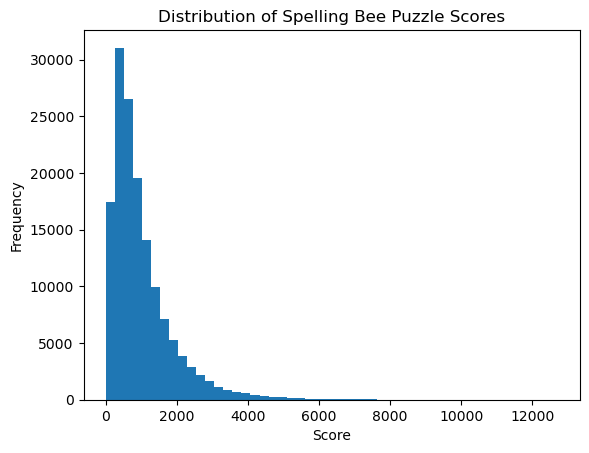

Max score: 12694, Puzzle: ['ESTRIAN']
Min score: 15, Puzzles: ['XPCRION', 'XKBEOJU', 'QWSTREI']
Median score: 758.0
Mean score: 1019.5


In [45]:
import matplotlib.pyplot as plt
import statistics

plt.hist(scores, bins=50)
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Spelling Bee Puzzle Scores")
plt.savefig("histogram.png")
plt.show()

# Fun statistics:
max_score = max(scores)
min_score = min(scores)
median_score = statistics.median(scores)
mean_score = statistics.mean(scores)

max_puzzle = [p for p in solutions_dict if solutions_dict[p][1] == max_score]
min_puzzle = [p for p in solutions_dict if solutions_dict[p][1] == min_score]

print(f"Max score: {max_score}, Puzzle: {max_puzzle}")
print(f"Min score: {min_score}, Puzzles: {min_puzzle}")
print(f"Median score: {median_score}")
print(f"Mean score: {round(mean_score, 1)}")

In [49]:
# Pasted statistics:
# Max score: 12694, Puzzle: ['ESTRIAN']
# Min score: 15, Puzzles: ['XPCRION', 'XKBEOJU', 'QWSTREI']
# Median score: 758.0
# Mean score: 1019.5

# The dictionary I am using include obscure words that the NYT does not,
# so through this solver there is a higher score found for each puzzle
# than if it were an actual NYT puzzle, because the NYT filters obscure words out.